In [75]:
from Nanodiffraction_s26MDALoad import load_scan, get_image # Stripped down version of off from dude.py

import time
from math import *
import skimage as skImg
import h5py, hdf5plugin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from matplotlib_scalebar.scalebar import ScaleBar
plt.rcParams.update({'font.size': 14}) 



import tkinter as tk
from tkinter import filedialog



# %matplotlib inline

In [76]:
# root = tk.Tk()
# root.withdraw()
# root.attributes('-topmost', True)
# file_path = filedialog.askopenfilename(
#     title="Select MDA file",
#     initialdir='/Users/smith.scott/Documents/Postdoc/Data/S26_20260211/data/mda',
#     filetypes=[("MDA files", "*.mda"), ("All files", "*.*")]
# )
# root.destroy()

# if file_path:
#     print(f"Selected file: {file_path}")
#     result = load_scan(file_path)
#     print(f"Loaded {result.ndim}-D scan with {len(result.detector_names)} detectors")
#     print(f"Image index range: {result.image_index_min} — {result.image_index_max}")
#     if result.h5 is not None:
#         print(f"HDF5 dataset shape: {result.h5['entry/data/data'].shape}")
#         result.h5.close()
# else:
#     print("No file selected.")


In [77]:
ScanNum = 82

file_path = f'/Users/smith.scott/Documents/Postdoc/Data/S26_20260211/data/mda/26idbSOFT_{ScanNum:04}.mda'
print(file_path)

/Users/smith.scott/Documents/Postdoc/Data/S26_20260211/data/mda/26idbSOFT_0082.mda


In [78]:
mda = load_scan(file_path)
print(mda.ndim)
img = get_image(mda, index=0)

Scan 82 loaded: 100 points in x, 101 points in y
2


In [79]:
#Preload h5df Data (.h5 files) to memory

t0 = time.time()
print("Loading all frames into RAM (slow once, fast forever)...")
with h5py.File(mda.h5.filename, 'r') as f:
    all_frames = f['/entry/data/data'][()]  # shape: (n_frames, height, width)
    sample_theta = f['/entry/instrument/26-ID-C/SAMTH'][()]
all_frames[all_frames > 2**31] = 0          # hot pixel masking
print(f"Load time: {time.time()-t0:.1f}s")
print(f"Sample Theta: {sample_theta}")

Loading all frames into RAM (slow once, fast forever)...
Load time: 67.7s
Sample Theta: 12.6


In [80]:
#Projective distortion along x correction factor
x_stretched = mda.positioner_x / np.sin(np.radians(sample_theta))
dx = np.mean(np.diff(x_stretched))
# print(f"scalebar dx = {dxS}")

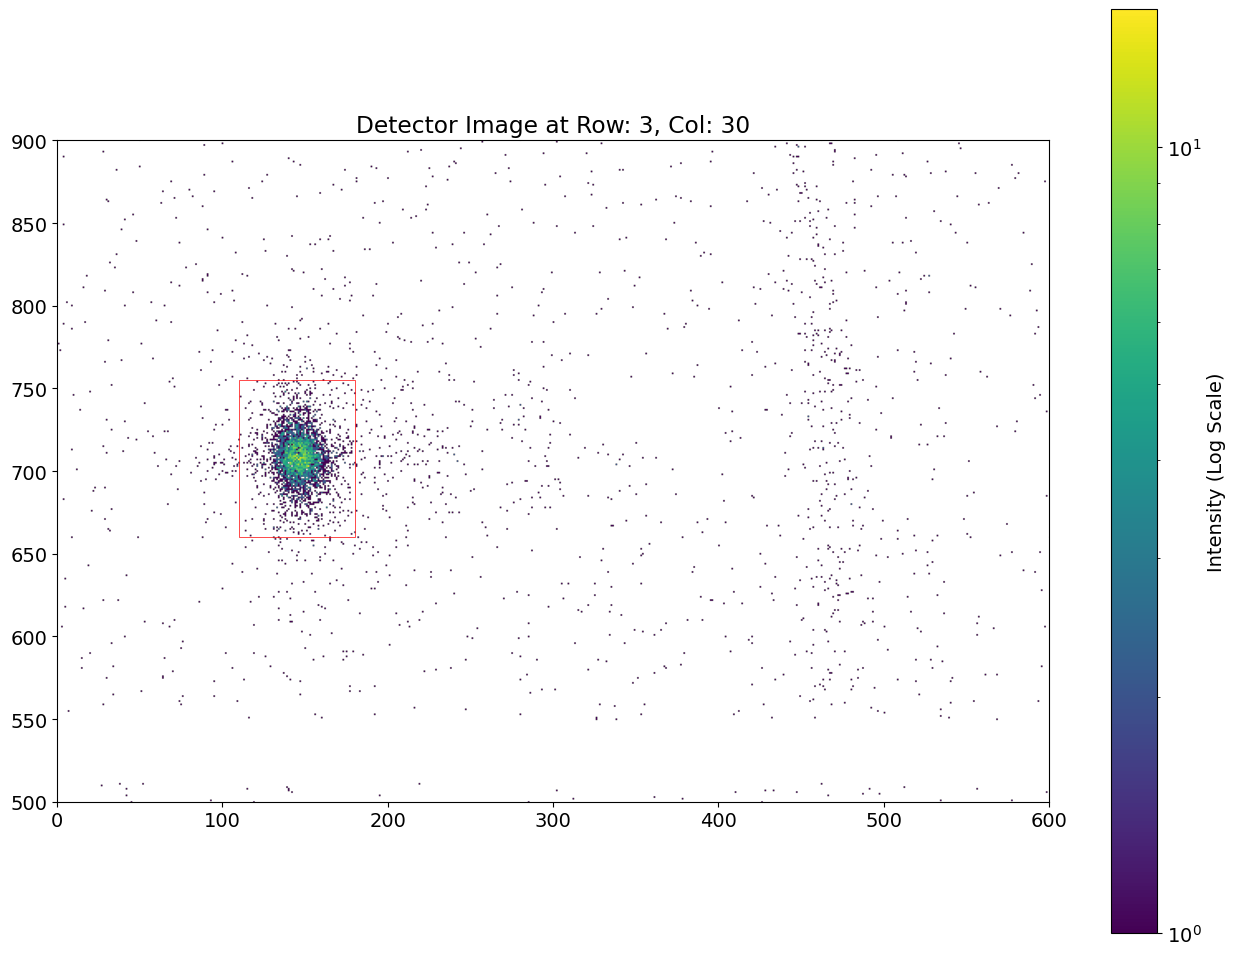

In [81]:
mda.ncol
mda.nrow

# Desired row and col for image
i = 3
j = 30

#ROI Parameters
xmin = 0
xmax = 600
ymin = 500
ymax = 900

lindex = (i * mda.ncol) + j

img = get_image(mda, index=lindex)

#Create plot and show ROI box
fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(img, norm=LogNorm(), cmap='viridis')
fig.colorbar(im, ax=ax, label='Intensity (Log Scale)')
ax.set_title(f"Detector Image at Row: {i}, Col: {j}")
ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)

# Define ROI bo0undaries (xmin, ymin, width, height)
roi_xmin = 110
roi_ymin = 660
roi_width = 70
roi_height = 95

# Create a Rectangle patch
roi_rect = patches.Rectangle(
    (roi_xmin, roi_ymin), roi_width, roi_height, 
    linewidth=0.5, edgecolor='r', facecolor='none'
)

# Add the patch to the Axes
ax.add_patch(roi_rect)

plt.show()

 # ROI Loading and Integration

In [82]:
# # Set ROI bouds
# ymin, ymax = roi_ymin, roi_ymin + roi_height
# xmin, xmax = roi_xmin, roi_xmin + roi_width

# t1 = time.time()
# intensity_1d = all_frames[:, ymin:ymax+1, xmin:xmax+1].sum(axis=(1,2))          #vectorized image
# intensity_2d = intensity_1d[:mda.nrow * mda.ncol].reshape(mda.nrow, mda.ncol)   #reshape into 2D array
# intensity_2d[1::2, :] = intensity_2d[1::2, ::-1]                                #reshape to account for snake scan ()

# print(f"ROI integration: {time.time()-t1:.3f}s")


# Weighted Centroid Calculation

In [83]:
# Calc indicies for ROI selection from ROI patch params
ymin, ymax = roi_ymin, roi_ymin + roi_height
xmin, xmax = roi_xmin, roi_xmin + roi_width

# Extract the ROI block
roi_block = all_frames[:, ymin:ymax+1, xmin:xmax+1] # Shape: (n_frames, h, w)

# Create coordinate grids for the ROI -- equivalent of meshgrid (matlab). 
# np.indices returns arrays representing the indices of the grid: shape will be (2, h, w)
yy, xx = np.indices(roi_block.shape[1:]) 
# print(xx)
# print(yy)

#Calculate Weighted Sums
# Multiply the intensity of every pixel by its coordinate, and sum over the height (axis 1) and width (axis 2)
tot_inten_1d = roi_block.sum(axis=(1, 2))
weighted_x_1d = np.sum(roi_block * xx, axis=(1, 2))
weighted_y_1d = np.sum(roi_block * yy, axis=(1, 2))


# Compute Centroids
# Use np.divide to handle potential zeros in total_intensity safely
cx_relative_1d = np.divide(weighted_x_1d, tot_inten_1d, out=np.zeros_like(weighted_x_1d,dtype=float), where=tot_inten_1d!=0)
cy_relative_1d = np.divide(weighted_y_1d, tot_inten_1d, out=np.zeros_like(weighted_x_1d,dtype=float), where=tot_inten_1d!=0)

# Shift from ROI-relative coordinates back to Global image coordinates
cx_relative_1d = cx_relative_1d + xmin
cy_relative_1d = cy_relative_1d + ymin

# Reshape 1d-->2d Intensity,Cx and Cy maps, and fix snake scan
tot_inten = tot_inten_1d[:mda.nrow * mda.ncol].reshape(mda.nrow, mda.ncol)     #reshape into 2D array
cx_global = cx_relative_1d[:mda.nrow * mda.ncol].reshape(mda.nrow, mda.ncol)   #reshape into 2D array
cy_global = cy_relative_1d[:mda.nrow * mda.ncol].reshape(mda.nrow, mda.ncol)   #reshape into 2D array

# Fix Snake Scan Raster -->
tot_inten[1::2, :] = tot_inten[1::2, ::-1]                                   #reshape to account for snake scan ()
cx_global[1::2, :] = cx_global[1::2, ::-1]                                   #reshape to account for snake scan ()
cy_global[1::2, :] = cy_global[1::2, ::-1]                                   #reshape to account for snake scan ()

### Plot Individually Total ROI Intensity, Center of Mass (CoM) X, & CoMY Maps

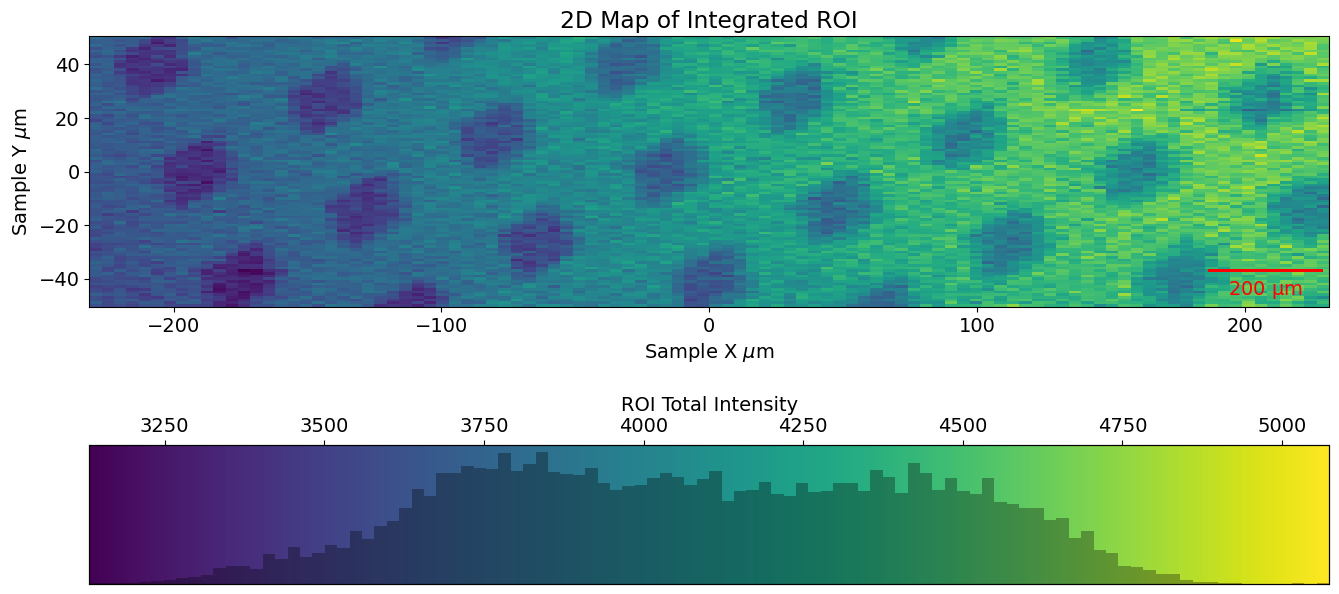

In [84]:
# Diffraction Intensity Map

#Make fig and Axes
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_aspect('equal')
ax.set_title("2D Map of Integrated ROI")
# Set labels for the main plot axes
ax.set_xlabel(r"Sample X $\mu$m")
ax.set_ylabel(r"Sample Y $\mu$m")

#plot image 
img = ax.pcolormesh(x_stretched,mda.positioner_y,tot_inten, cmap='viridis')


#  ---   ---


#Colorbar with Superimposed Histogram
cbar = fig.colorbar(img, ax=ax, label='ROI Total Intensity', orientation = 'horizontal')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

hist_ax = cbar.ax.twinx() # Create a twin axes on the colorbar axes

# Plot the histogram of data
hist_ax.hist(tot_inten.flatten(), bins=100, range=(tot_inten.min(), tot_inten.max()),
             color='black', alpha=0.3, density=True)

# Clean up the histogram axes
hist_ax.set_yticks([])
hist_ax.set_ylim(bottom=0)


#  ---   ---


# Scalebar
scalebar = ScaleBar(dx=dx, units="um", location="lower right", color="red",box_alpha=0.0) 
ax.add_artist(scalebar)

plt.show()

X Center of Mass

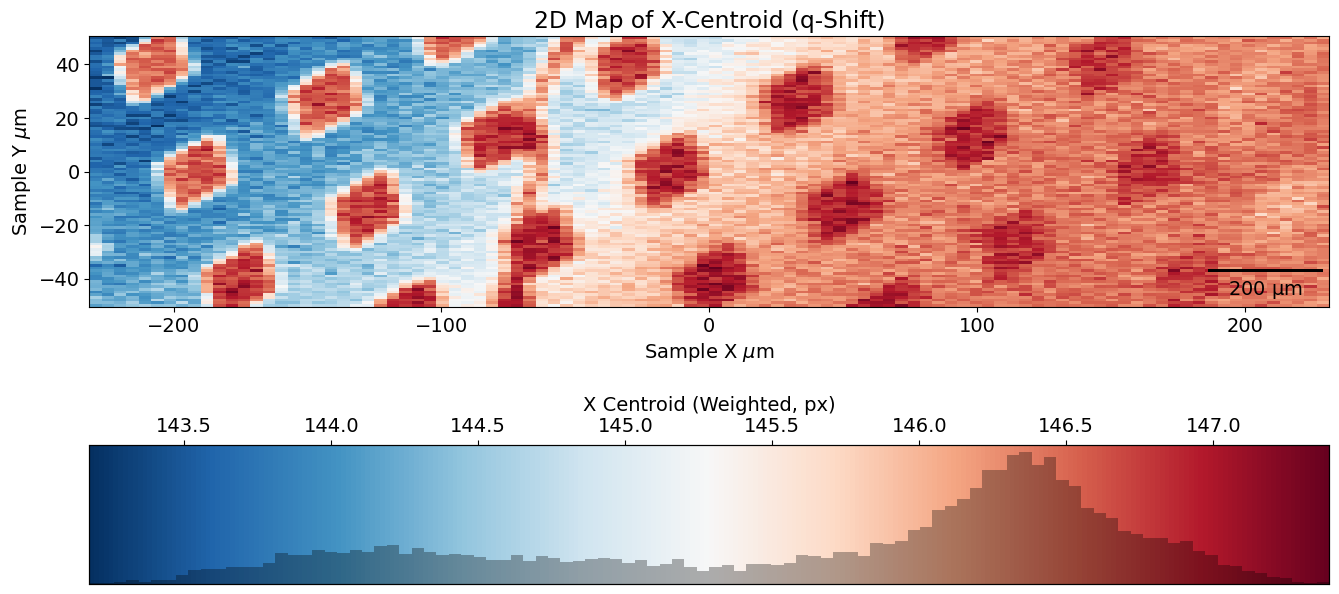

In [85]:
# X Center of Mass (Weighted Centroid)

#Make fig and Axes
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_aspect('equal')
ax.set_title("2D Map of X-Centroid (q-Shift)")
# Set labels for the main plot axes
ax.set_xlabel(r"Sample X $\mu$m")
ax.set_ylabel(r"Sample Y $\mu$m")

#plot image 
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cx_global, cmap='managua_r')
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cx_global, cmap='RdYlBu_r')
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cx_global, cmap='berlin')
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cx_global, cmap='BrBG_r')
img = ax.pcolormesh(x_stretched, mda.positioner_y, cx_global, cmap='RdBu_r')


#  ---   ---


#Colorbar with Superimposed Histogram
cbar = fig.colorbar(img, ax=ax, label='X Centroid (Weighted, px)', orientation = 'horizontal')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

hist_ax = cbar.ax.twinx() # Create a twin axes on the colorbar axes

# Plot the histogram of data
hist_ax.hist(cx_global.flatten(), bins=100, range=(cx_global.min(), cx_global.max()),
             color='black', alpha=0.3, density=True)

# Clean up the histogram axes
hist_ax.set_yticks([])
hist_ax.set_ylim(bottom=0)


#  ---   ---


# Scalebar
scalebar = ScaleBar(dx=dx, units="um", location="lower right", color="black",box_alpha=0.0) 
ax.add_artist(scalebar)

plt.show()

### Y Center of Mass

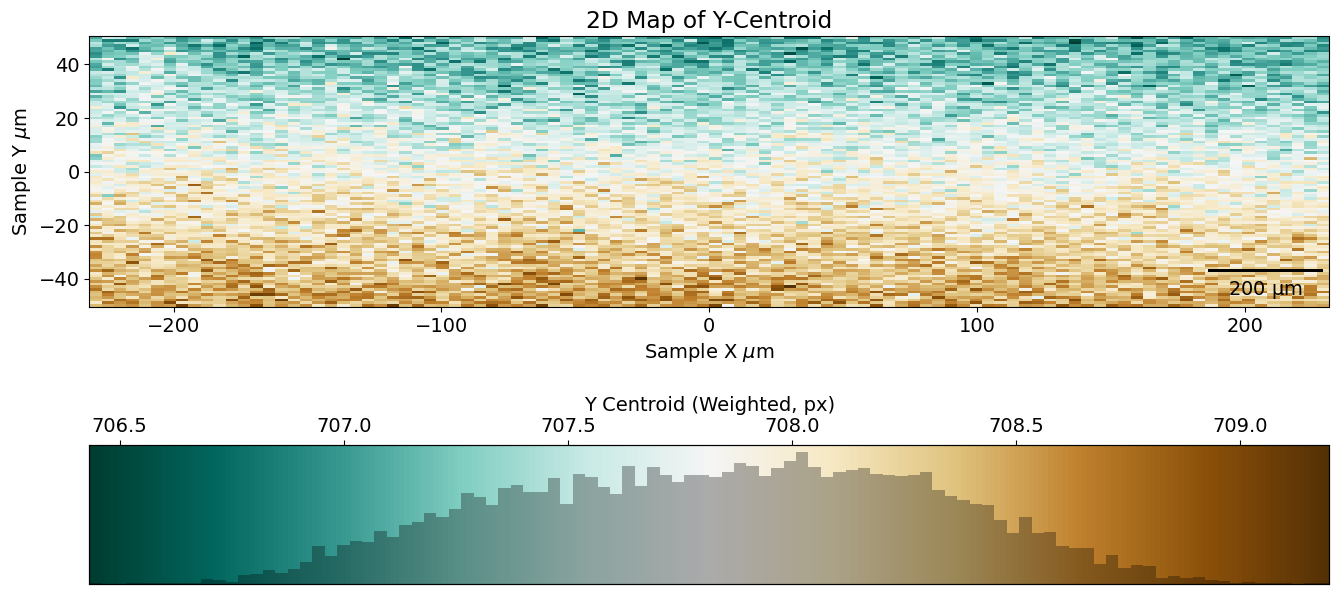

In [86]:
# Y Center of Mass (Weighted Centroid)

#Make fig and Axes
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_aspect('equal')
ax.set_title("2D Map of Y-Centroid")
# Set labels for the main plot axes
ax.set_xlabel(r"Sample X $\mu$m")
ax.set_ylabel(r"Sample Y $\mu$m")

#plot image 
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cy_global, cmap='managua_r')
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cy_global, cmap='RdYlBu_r')
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cy_global, cmap='berlin')
img = ax.pcolormesh(x_stretched, mda.positioner_y, cy_global, cmap='BrBG_r')
# img = ax.pcolormesh(x_stretched, mda.positioner_y, cy_global, cmap='RdBu_r')


#  ---   ---


#Colorbar with Superimposed Histogram
cbar = fig.colorbar(img, ax=ax, label='Y Centroid (Weighted, px)', orientation = 'horizontal')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

hist_ax = cbar.ax.twinx() # Create a twin axes on the colorbar axes

# Plot the histogram of data
hist_ax.hist(cy_global.flatten(), bins=100, range=(cy_global.min(), cy_global.max()),
             color='black', alpha=0.3, density=True)

# Clean up the histogram axes
hist_ax.set_yticks([])
hist_ax.set_ylim(bottom=0)


#  ---   ---


# Scalebar
scalebar = ScaleBar(dx=dx, units="um", location="lower right", color="black",box_alpha=0.0) 
ax.add_artist(scalebar)

plt.show()